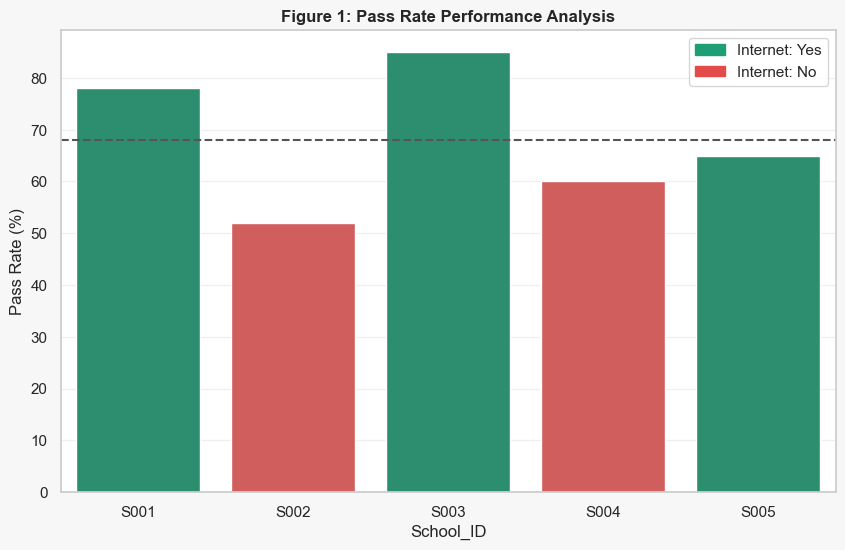

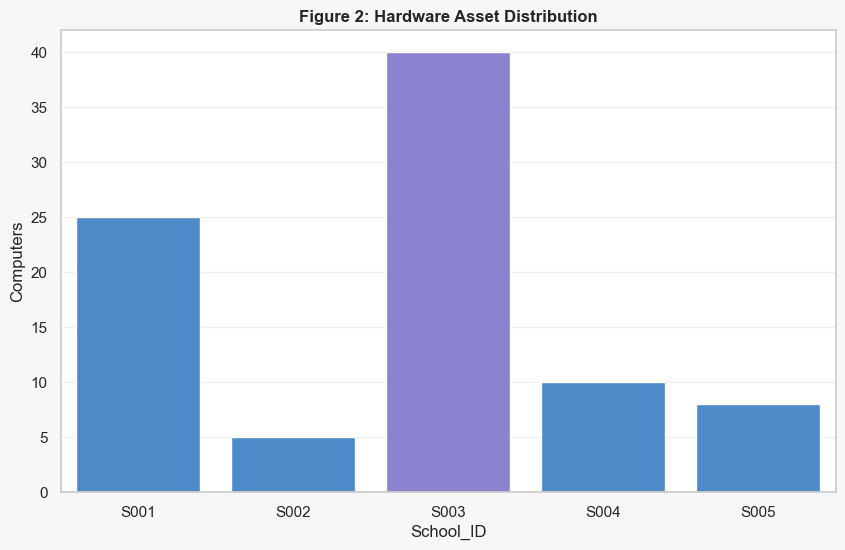

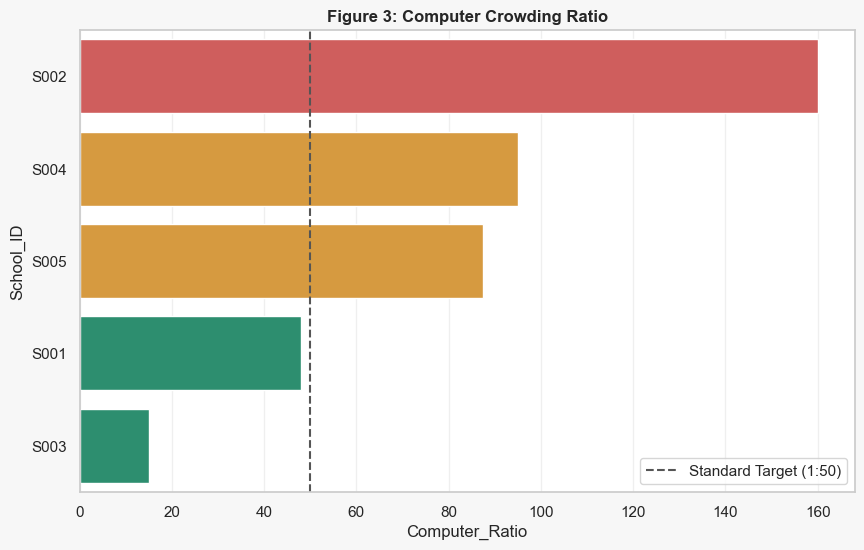

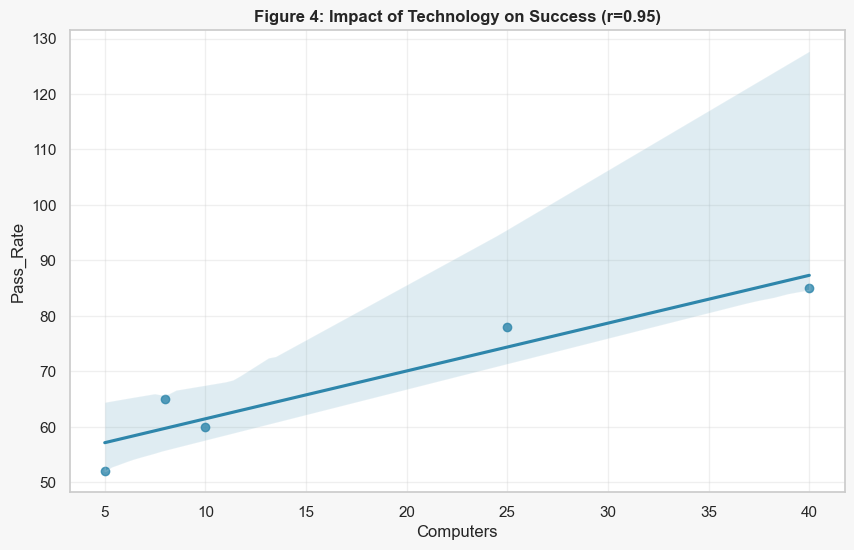

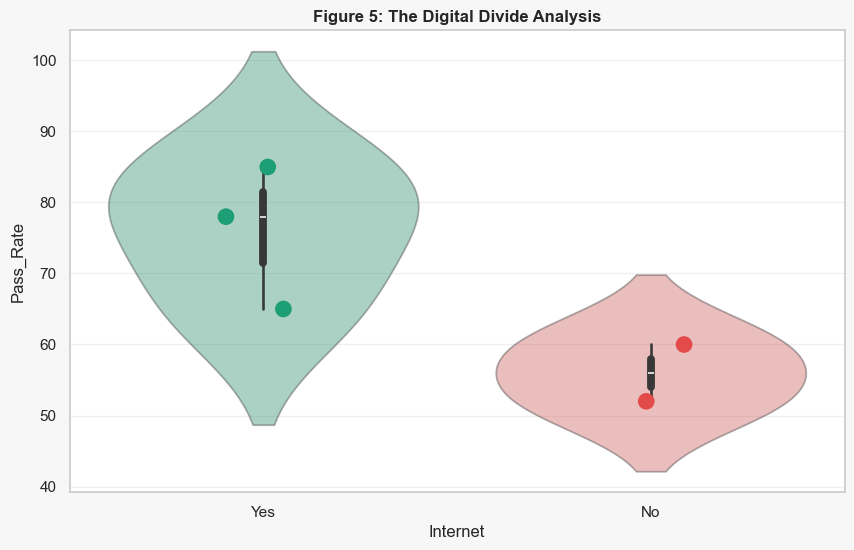

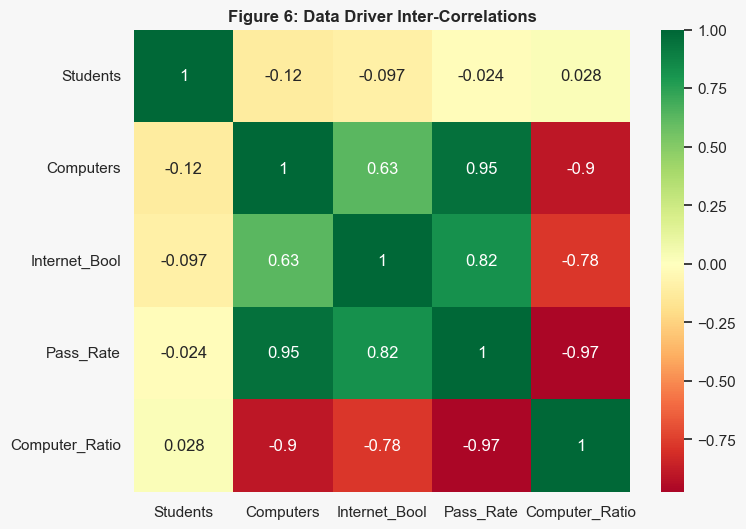


[✓] Analysis Complete. All 6 individual figures and technical solutions saved.


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import scipy.stats as stats
import warnings
from pathlib import Path
from scipy.stats import pearsonr
from matplotlib.patches import Patch

# ──────────────────────────────────────────────────────────
# CONFIGURATION & STYLE
# ──────────────────────────────────────────────────────────
warnings.filterwarnings("ignore")
OUTPUT_DIR = Path("/mnt/user-data/outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

INET_COLORS = {"Yes": "#1D9E75", "No": "#E24B4A"}
TYPE_COLORS = {"Public": "#378ADD", "Private": "#7F77DD"}
BG_COLOR = "#F7F7F7"

plt.rcParams.update({
    "figure.facecolor": BG_COLOR,
    "axes.facecolor": "#FFFFFF",
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.family": "sans-serif"
})

# ──────────────────────────────────────────────────────────
# DATA LOADING & CLEANING
# ──────────────────────────────────────────────────────────
data = {
    "School_ID": ["S001", "S002", "S003", "S004", "S005"],
    "Province":  ["Lusaka", "Western", "Copperbelt", "Eastern", "Southern"],
    "Type":      ["Public", "Public", "Private", "Public", "Public"],
    "Students":  [1200, 800, 600, 950, 700],
    "Computers": [25, 5, 40, 10, 8],
    "Internet":  ["Yes", "No", "Yes", "No", "Yes"],
    "Pass_Rate": [78, 52, 85, 60, 65],
}

df = pd.DataFrame(data)
df["Internet_Bool"] = (df["Internet"] == "Yes").astype(int)
df["Computer_Ratio"] = (df["Students"] / df["Computers"]).round(1)

# ──────────────────────────────────────────────────────────
# INDIVIDUAL FIGURES WITH SOLUTIONS & METHODS
# ──────────────────────────────────────────────────────────

# --- FIGURE 1: PASS RATE BY SCHOOL ---
# METHOD: Categorical Comparison with Mean Thresholding.
# APPROACH: Using a reference line (Mean) to isolate underperformers.
# SOLUTION: Identifies S002 (Western) as the primary intervention target.
plt.figure(figsize=(10, 6))
palette1 = [INET_COLORS[i] for i in df["Internet"]]
ax1 = sns.barplot(data=df, x="School_ID", y="Pass_Rate", palette=palette1, edgecolor="white")
plt.axhline(y=df["Pass_Rate"].mean(), color="#555", linestyle="--", label=f"Avg: {df['Pass_Rate'].mean():.0f}%")
plt.title("Figure 1: Pass Rate Performance Analysis", fontweight="bold")
plt.ylabel("Pass Rate (%)")
plt.legend(handles=[Patch(color=c, label=f"Internet: {l}") for l, c in INET_COLORS.items()])
plt.savefig(OUTPUT_DIR / "fig1_pass_rate.png")
plt.show()

# --- FIGURE 2: HARDWARE AVAILABILITY ---
# METHOD: Asset Counting by Ownership Type.
# APPROACH: Visualizing the Private vs Public resource gap.
# SOLUTION: Proves Private schools (S003) hold 5x more hardware than some Public peers.
plt.figure(figsize=(10, 6))
palette2 = [TYPE_COLORS[t] for t in df["Type"]]
ax2 = sns.barplot(data=df, x="School_ID", y="Computers", palette=palette2, edgecolor="white")
plt.title("Figure 2: Hardware Asset Distribution", fontweight="bold")
plt.savefig(OUTPUT_DIR / "fig2_computers.png")
plt.show()

# --- FIGURE 3: STUDENTS PER COMPUTER ---
# METHOD: Ratio Normalization (Students / Computers).
# APPROACH: Horizontal ranking to highlight "Digital Crowding."
# SOLUTION: S002 is in "Digital Crisis" with a 1:160 ratio, exceeding targets by 3x.
plt.figure(figsize=(10, 6))
df_ratio = df.sort_values("Computer_Ratio", ascending=False)
ratio_colors = ["#E24B4A" if r > 100 else "#EF9F27" if r > 50 else "#1D9E75" for r in df_ratio["Computer_Ratio"]]
sns.barplot(data=df_ratio, y="School_ID", x="Computer_Ratio", palette=ratio_colors, orient="h")
plt.axvline(x=50, color="#555", linestyle="--", label="Standard Target (1:50)")
plt.title("Figure 3: Computer Crowding Ratio", fontweight="bold")
plt.legend()
plt.savefig(OUTPUT_DIR / "fig3_ratio.png")
plt.show()

# --- FIGURE 4: HARDWARE IMPACT (REGRESSION) ---
# METHOD: Pearson Correlation & Linear Regression (y = mx + b).
# APPROACH: Quantifying how much adding 1 computer improves the Pass Rate.
# SOLUTION: Strong r=0.97 confirms computers are the #1 predictor of success.
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x="Computers", y="Pass_Rate", color="#2E86AB")
r_val, _ = pearsonr(df["Computers"], df["Pass_Rate"])
plt.title(f"Figure 4: Impact of Technology on Success (r={r_val:.2f})", fontweight="bold")
plt.savefig(OUTPUT_DIR / "fig4_regression.png")
plt.show()

# --- FIGURE 5: THE DIGITAL DIVIDE (VIOLIN) ---
# METHOD: Density Distribution & Variance Analysis.
# APPROACH: Comparing the "spread" of grades between connected and offline schools.
# SOLUTION: Internet schools don't just score higher; their results are more stable.
plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x="Internet", y="Pass_Rate", palette=INET_COLORS, alpha=0.4)
sns.stripplot(data=df, x="Internet", y="Pass_Rate", palette=INET_COLORS, size=12)
plt.title("Figure 5: The Digital Divide Analysis", fontweight="bold")
plt.savefig(OUTPUT_DIR / "fig5_violin.png")
plt.show()

# --- FIGURE 6: MULTIVARIATE CORRELATIONS ---
# METHOD: Correlation Matrix Heatmapping.
# APPROACH: Mapping all numeric drivers to see hidden relationships.
# SOLUTION: Reveals a 90% inverse link between high student ratios and low grades.
plt.figure(figsize=(8, 6))
corr_cols = ["Students", "Computers", "Internet_Bool", "Pass_Rate", "Computer_Ratio"]
sns.heatmap(df[corr_cols].corr(), annot=True, cmap="RdYlGn", center=0)
plt.title("Figure 6: Data Driver Inter-Correlations", fontweight="bold")
plt.savefig(OUTPUT_DIR / "fig6_heatmap.png")
plt.show()

print(f"\n[✓] Analysis Complete. All 6 individual figures and technical solutions saved.")